# APR + Fit Workflow


### This Notebook's Operations

This workflow starts from `FILENAME_INPUT`, creates a calibrated source file, then appends all derived analysis runs into the same output file.

1. `FILENAME_INPUT` -> calibration -> `FILENAME_OUTPUT`
2. `FILENAME_OUTPUT` -> `apr` with `mode="append"` -> `FILENAME_OUTPUT`
3. `FILENAME_OUTPUT` -> `lifetime_fit` with `mode="append"` -> same `FILENAME_OUTPUT`

The exported file therefore contains the APR decay output and the lifetime-fit products together under `/output`.

Full pipeline: Adaptive Pixel Reassignment (APR) followed by per-pixel
exponential lifetime estimation via IRF-convolved model fitting.

**Steps**
1. Calibrate the raw `.h5` acquisition file
2. Load calibrated data and metadata
3. Inspect photon flux per SPAD channel
4. *(optional)* Apply APR — pixel reassignment overwrites `data_input` in memory
5. Visualise raw vs. reassigned intensity
6. Sum channels applying calibration timing shifts
7. Preview single-pixel fit
8. Run per-pixel fit to generate lifetime maps
9. Visualise and export results


In [ ]:
# ── File paths ────────────────────────────────────────────────────────────
FILE_REFERENCE = '/mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5'
FILENAME_INPUT = '/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5'

DATA_KEY             = "data"   # "data" or "data_channels_extra"

# ── Calibration parameters ────────────────────────────────────────────────
TAU_REF          = None          # known reference lifetime (ns)
REFERENCE_TYPE   = "ref"        # "ref" or "irf"
FIT_MODE         = "model_shift"
FIT_TYPE         = "likelihood"
LASER_FREQ_MHZ   = None
LASER_PERIOD_NS  = None
CHANNEL_SKEW_SOURCE = "ref"
OVERWRITE        = True

# ── APR parameters ────────────────────────────────────────────────────────
DO_APR        = True            # set False to skip reassignment
ROI           = None            # e.g. (1000, 1750, 1200, 1950), or None
REF_CHANNEL   = 12              # reference detector (centre of 5×5 array)
USF           = 100             # up-sampling factor for shift estimation
REASSIGN_MODE = "interp"        # "interp" or "fft"

# ── Fit parameters ────────────────────────────────────────────────────────
FIT_INITIAL_TAU = 4.0           # initial lifetime guess (ns)
FIT_INITIAL_dT  = 1.0           # initial IRF shift guess (ns)
FIT_INITIAL_C   = 1.0           # initial amplitude guess
FIT_MODE_PIXEL  = "irf_shift"   # convolution mode passed to perform_fit_data
FIT_TYPE_PIXEL  = "likelihood"  # "likelihood" or "leastsq"


THRESHOLD = 0.05
LIFETIME_BOUNDS = [1.0, 8.0]

FILENAME_OUTPUT = FILENAME_INPUT.replace(".h5", "_fit_workflow.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILENAME_INPUT}")
print(f"Calibration and output products to: {FILENAME_OUTPUT}")


## Imports

In [26]:
from pathlib import Path
import importlib
import sys

# ── Locate repository root (contains 'src/') ──────────────────────────────
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SRC = str(ROOT / "src")
if SRC in sys.path:
    sys.path.remove(SRC)
sys.path.insert(0, SRC)

# ── Optional sibling repo: BrightEyes-MCS-File ────────────────────────────
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists():
    MCS_FILE_SRC_STR = str(MCS_FILE_SRC)
    if MCS_FILE_SRC_STR in sys.path:
        sys.path.remove(MCS_FILE_SRC_STR)
    sys.path.insert(0, MCS_FILE_SRC_STR)

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# APR
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gr

# Calibration & alignment
import brighteyes_mcs_file.alignment as alignment_module
alignment_module = importlib.reload(alignment_module)

from brighteyes_mcs_file.alignment import Alignment
from brighteyes_mcs_file import (
    H5OutputProduct,
    calibrate_h5_file,
    show_h5_structure_html,
    sum_channel_applying_shifts,
    write_h5_output_run,
)

# Graph tools
import brighteyes_flim.graph_tools as graph
graph = importlib.reload(graph)


In [ ]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing
the aligned per-channel IRF and reference traces, the per-channel timing offsets (channel skew),
and the laser timing parameters.
If `OVERWRITE = True` the calibration is recomputed even if a calibrated file already exists.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing
> reference. `channel_skew_fit_upsampling=10` enables sub-bin precision in the cross-correlation.


In [28]:
calibrate_h5_file(
    FILENAME_INPUT,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILENAME_OUTPUT,
    overwrite=OVERWRITE,
)


Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_calib.h5


## Load Calibrated Data

All arrays and metadata are read from the calibrated HDF5 file.

| Variable | Shape | Description |
|---|---|---|
| `data_input` | `(rep, z, y, x, t_bins, channels)` | Raw photon counts |
| `channel_skew` | `(channels,)` | Per-channel timing offset [bins] |
| `irf_common_delay_realigned` | `(t_bins, channels)` | Aligned IRF traces |
| `ref_common_delay_realigned` | `(t_bins, channels)` | Aligned reference-dye traces |
| `laser_freq_mhz` | scalar | Laser repetition frequency [MHz] |
| `laser_period_ns` | scalar | Laser period [ns] |
| `nbin` | scalar | Number of TCSPC time bins per period |
| `pixel_size_x_um` | scalar | Lateral pixel size [µm] |
| `pxdwelltime` | scalar | Pixel dwell time [µs] |


In [29]:
with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata    = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                 = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew               = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned = calibration["aligned/irf_trace"][:]

# Time axis in ns (used for fitting)
t = np.arange(nbin, dtype=float) * laser_period_ns / nbin

print(f"Laser timing : {laser_freq_mhz:.4f} MHz  ({laser_period_ns:.4f} ns period)")
print(f"data_input   : {data_input.shape}  (rep, z, y, x, t_bins, channels)")
print(f"t axis       : {t[0]:.3f} … {t[-1]:.3f} ns  ({nbin} bins)")


Laser timing : 40.0000 MHz  (25.0000 ns period)
data_input   : (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)
t axis       : 0.000 … 24.725 ns  (91 bins)


## Photon Flux Per SPAD Channel

Compute the total photon count and the average count rate (flux) for each SPAD channel.

In [30]:
n_foton_per_channel = np.sum(data_input, axis=(0, 1, 2, 3, 4))
n_rep, n_frame, nx, ny = (data_input.shape[i] for i in (0, 1, 2, 3))
n_px_total  = n_rep * n_frame * nx * ny
total_time_s = n_px_total * pxdwelltime * 1e-6

flux_per_channel = n_foton_per_channel / total_time_s   # shape: (n_channels,)
flux_total       = flux_per_channel.sum()

print(f"Pixel dwell time         : {pxdwelltime:.3f} µs")
print(f"Total acquisition time   : {total_time_s:.4f} s")
print(f"Total flux               : {flux_total * 1e-3:.2f} kHz")
print("\nFlux per channel (kHz):")
for i, val in enumerate(flux_per_channel, 1):
    print(f"{val * 1e-3:<8.2f}", end="" if i % 5 != 0 else "\n")


Pixel dwell time         : 182.000 µs
Total acquisition time   : 47.7102 s
Total flux               : 2664.60 kHz

Flux per channel (kHz):
68.30   85.93   94.59   88.11   71.06   
90.55   122.57  138.08  122.35  95.79   
105.57  147.73  165.14  141.55  100.24  
98.18   133.07  145.55  124.73  90.82   
76.62   95.25   102.10  89.77   70.95   


## APR — Pixel Reassignment *(optional)*

Controlled by `DO_APR` in the parameters cell.
When enabled, the shift vectors are estimated from the intensity image (sum over time bins)
and the reassignment is then applied **independently to each time bin**, fully preserving the
TCSPC decay information required for phasor analysis.

`data_input` is overwritten in memory with the spatially-reassigned array;
all downstream cells are unaffected.

Shift vectors are printed in **nanometres** for physical interpretability
(pixel size is read from the metadata).


Shift vectors (dy, dx) per channel [nm]:
[[-185.518591    -98.63013699]
 [-164.38356164  -14.09001957]
 [-141.68297456   67.31898239]
 [-104.89236791  150.29354207]
 [ -75.14677104  231.70254403]
 [-129.94129159 -133.07240705]
 [ -93.9334638   -52.44618395]
 [ -67.31898239   32.87671233]
 [ -39.13894325  116.63405088]
 [ -11.74168297  194.91193738]
 [ -54.01174168 -163.60078278]
 [ -25.04892368  -82.97455969]
 [   0.            0.        ]
 [  25.04892368   84.54011742]
 [  47.74951076  165.94911937]
 [  14.09001957 -194.91193738]
 [  36.00782779 -113.50293542]
 [  61.83953033  -31.3111546 ]
 [  90.80234834   51.66340509]
 [ 116.63405088  136.98630137]
 [  72.79843444 -215.26418787]
 [ 103.32681018 -140.90019569]
 [ 132.28962818  -64.18786693]
 [ 161.25244618   25.83170254]
 [ 179.25636008  109.5890411 ]]


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


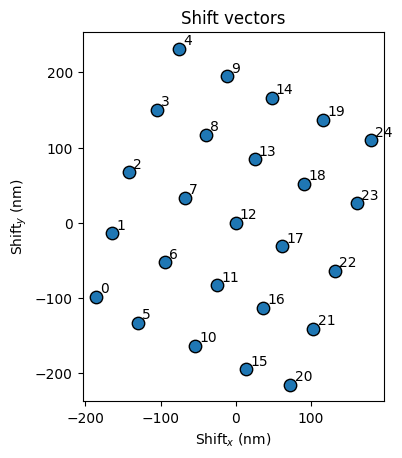

Reassigning time bins: 100%|██████████| 91/91 [01:04<00:00,  1.40it/s]

APR complete — data_input shape: (1, 1, 512, 512, 91, 25)


In [31]:
if DO_APR:
    # Select first rep and z-plane → (y, x, t_bins, channels)
    image_4D = data_input[0, 0, ...]

    # Apply spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]
        print(f"ROI applied — cropped shape: {image_4D.shape}")

    # Intensity image (y, x, channels) — used only for shift estimation
    image_intensity = np.sum(image_4D, axis=-2)

    # Estimate sub-pixel shift vectors
    shift_vectors, estimation_error = apr.ShiftVectors(
        image_intensity, usf=USF, ref=REF_CHANNEL
    )

    pixel_size_nm    = pixel_size_x_um * 1000
    shift_vectors_nm = shift_vectors * pixel_size_nm

    print("Shift vectors (dy, dx) per channel [nm]:")
    print(shift_vectors_nm)
    gr.PlotShiftVectors(shift_vectors_nm)
    plt.show()

    # Reassign each time bin independently
    n_y, n_x, n_bins, n_ch = image_4D.shape
    reassigned = np.empty_like(image_4D, dtype=np.float32)

    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned[:, :, b, :] = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )

    # Wrap back to (1, 1, y, x, t_bins, channels) and overwrite data_input
    data_input = reassigned[np.newaxis, np.newaxis, ...]
    print(f"APR complete — data_input shape: {data_input.shape}")

else:
    print("APR skipped (DO_APR = False)")


In [32]:
if DO_APR:
    if FILENAME_OUTPUT is not None:
        apr_common_attrs = {
            "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
            "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
            "source_metadata_path": "/raw/metadata",
            "source_axes_path": "/raw/axes",
            "time_axis_source": "/raw/axes/digital_time_ns",
            "time_bin_ns": laser_period_ns / nbin,
            "laser_frequency_mhz": laser_freq_mhz,
            "laser_period_ns": laser_period_ns,
        }
        apr_summed = data_input.sum(axis=-1)
        target_path, output_run_id = write_h5_output_run(
            FILENAME_OUTPUT,
            "apr",
            [
                H5OutputProduct(
                    "spad",
                    data_input,
                    attrs={
                        **apr_common_attrs,
                        "data_role": "apr_reassigned_spad_detector_counts",
                        "axis_order": "repetition,z,y,x,time_bin,detector_channel",
                    },
                ),
                H5OutputProduct(
                    "apr",
                    apr_summed,
                    attrs={
                        **apr_common_attrs,
                        "data_role": "apr_reassigned_channel_summed_decay",
                        "axis_order": "repetition,z,y,x,time_bin",
                        "source_data_path": "/output/{run_id}/products/spad",
                    },
                )
            ],
            mode="append",
            output_path=None,
            output_key_overwrite=True,
            output_type="image_tool",
            tool_name="APR Reassignment",
            algorithm_name="adaptive_pixel_reassignment",
            parameters={
                "ref_channel": REF_CHANNEL,
                "usf": USF,
                "reassign_mode": REASSIGN_MODE,
                "roi_json": [] if ROI is None else list(ROI),
                "data_key": DATA_KEY,
                "calibration_product": CALIBRATION_PRODUCT,
            },
            metadata={
                **apr_common_attrs,
                "pixel_size_x_um": pixel_size_x_um,
                "pixel_dwell_time_us": pxdwelltime,
                "output_nrep": data_input.shape[0],
                "output_nz": data_input.shape[1],
                "output_ny": data_input.shape[2],
                "output_nx": data_input.shape[3],
                "output_time_bins": data_input.shape[-2],
                "apr_summed_path": "/output/{run_id}/products/apr",
                "selected_channel_count": data_input.shape[-1],
                "shift_vectors_path": "/output/{run_id}/intermediates/shift_vectors",
            },
            axes=[H5OutputProduct("time_ns", t, attrs={"axis": "time", "units": "ns"})],
            attrs={
                **apr_common_attrs,
                "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
                "output_axis_order": "repetition,z,y,x,time_bin",
                "output_data_path": "/output/{run_id}/products/apr",
                "all_channel_output_data_path": "/output/{run_id}/products/spad",
                "shift_vectors_path": "/output/{run_id}/intermediates/shift_vectors",
            },
            set_default=True,
            intermediates=[
                H5OutputProduct(
                    "shift_vectors",
                    shift_vectors,
                    attrs={
                        "axes": "detector_channel,shift_component",
                        "shift_components_json": ["dy", "dx"],
                        "units": "pixels",
                    },
                )
            ],
        )
        PIPELINE_H5 = target_path
        APR_OUTPUT_RUN_ID = output_run_id
        APR_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/spad"
        APR_SUMMED_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/apr"
        print(f"Saved {output_run_id} -> {target_path}")
    else:
        PIPELINE_H5 = FILENAME_OUTPUT
        APR_OUTPUT_RUN_ID = ""
        APR_OUTPUT_DATA_PATH = f"/raw/{CALIBRATION_PRODUCT}"
        APR_SUMMED_OUTPUT_DATA_PATH = ""
        print("Export skipped (FILENAME_OUTPUT = None).")
else:
    PIPELINE_H5 = FILENAME_OUTPUT
    APR_OUTPUT_RUN_ID = ""
    APR_OUTPUT_DATA_PATH = f"/raw/{CALIBRATION_PRODUCT}"
    APR_SUMMED_OUTPUT_DATA_PATH = ""
    print("APR skipped (DO_APR = False)")


Saved apr -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_fit_workflow.h5


## APR — Before / After Intensity Comparison

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.
Both images are displayed with a physical scale bar and a calibrated colour scale
(counts per pixel dwell time).

**What to expect:**
- The APR image should appear sharper than the raw (finer features better resolved).
- The total intensity should be conserved; a small loss at the borders is normal
  (photons shifted outside the field of view are discarded by the interpolation).


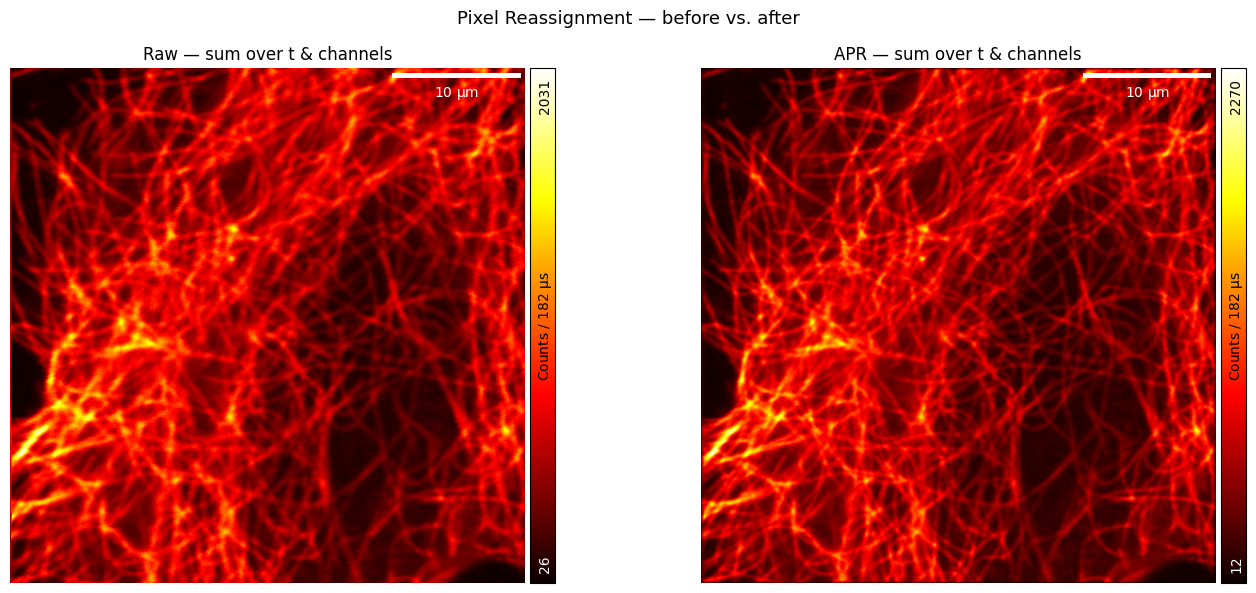

Raw image — min: 26  max: 2031
APR image — min: 12.0  max: 2270.0
Total counts — Raw: 127128805  APR: 128691120
Intensity conservation: 101.23% of raw counts retained


In [33]:
if DO_APR:
    # Sum over t_bins (axis -2) and channels (axis -1) → 2-D intensity map (y, x)
    intensity_raw = np.sum(image_4D,   axis=(-2, -1))
    intensity_apr = np.sum(reassigned, axis=(-2, -1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Use ShowImg to display images with a physical scale bar and calibrated colour scale,
    # matching the format used throughout the rest of the pipeline.
    gr.ShowImg(intensity_raw, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[0])
    axes[0].set_title("Raw — sum over t & channels")

    gr.ShowImg(intensity_apr, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[1])
    axes[1].set_title("APR — sum over t & channels")

    fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
    print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")
    print(f"Total counts — Raw: {intensity_raw.sum():.0f}  APR: {intensity_apr.sum():.0f}")
    print(f"Intensity conservation: {100 * intensity_apr.sum() / intensity_raw.sum():.2f}% of raw counts retained")

else:
    print("DO_APR = False — skipping before/after comparison.")

## Sum Channels Applying Calibration Timing Shifts

Before computing phasors, the per-channel TCSPC traces are summed across all 25 SPAD channels
with the timing-skew correction applied along the time axis (`sum_channel_applying_shifts`).
This yields a single spatially-resolved decay trace per pixel.

Three variants are computed for diagnostic purposes:
- **no alignment** — raw sum with no skew correction (reference only).
- **aligned** (default) — shift-corrected sum; used for all downstream analysis.
- **reversed** — sum with shifts applied in the opposite direction; used by
  `plot_channel_skew_correction` to verify that the calibration direction is correct.

In [34]:
data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed  = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())

data_summed_rev = sum_channel_applying_shifts(
    data_input, channel_skew, axis=(), reverse_shifts=False
)[0, 0, ...]
irf_summed_rev = sum_channel_applying_shifts(
    irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False
)

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

print("data_summed :", data_summed.shape, "  (y, x, t_bins)")
print("irf_summed  :", irf_summed.shape)


Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed : (512, 512, 91)   (y, x, t_bins)
irf_summed  : (91,)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

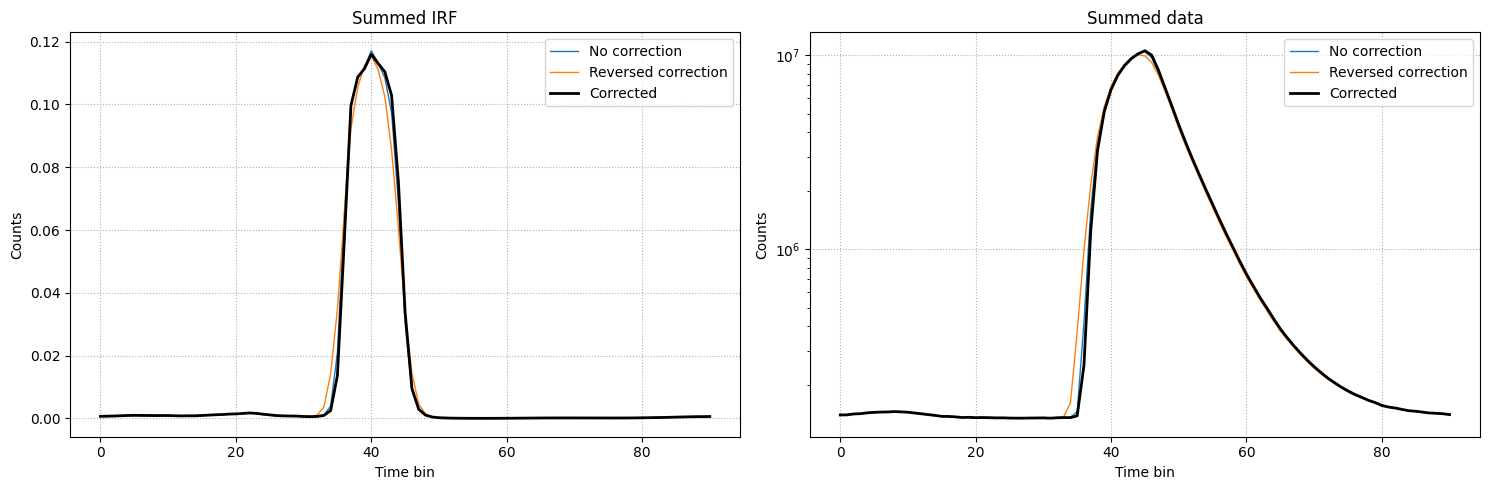

In [35]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)


## Preview — Single-Pixel Fit

Fit the central pixel of the summed image as a sanity check before running the
full per-pixel loop.


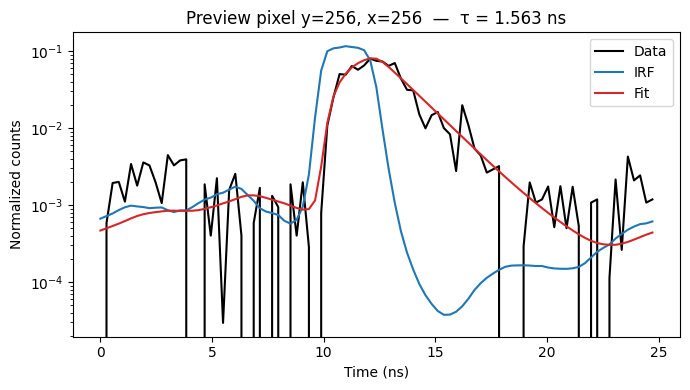

Fit result: {'C': 1.0, 'dT': 9.40054389756577e-09, 'dT_ns': 2.5825670048257613e-09, 'tau': 1.5626694744352008, 'params': {'C': 1.0, 'dT': 9.40054389756577e-09, 'tau': 1.5626694744352008}, 'parameter_names': ['C', 'dT', 'tau'], 'param_names': ['C', 'dT', 'tau'], 'param_values': array([1.00000000e+00, 9.40054390e-09, 1.56266947e+00]), 'param_errors': array([       nan, 0.30858317, 0.11356909]), 'fit': array([0.00046906, 0.00050113, 0.00053683, 0.00057613, 0.00062245,
       0.00067367, 0.00072415, 0.0007627 , 0.00079215, 0.00081192,
       0.00083062, 0.00084724, 0.00084934, 0.00084366, 0.00084568,
       0.00084681, 0.00086267, 0.00089522, 0.00094149, 0.00099179,
       0.00105559, 0.0011195 , 0.0011957 , 0.00128387, 0.00133869,
       0.00134212, 0.00130954, 0.00124569, 0.00117806, 0.00111558,
       0.00105587, 0.00098674, 0.00092053, 0.00087635, 0.00088972,
       0.00115081, 0.00318231, 0.01170329, 0.02588711, 0.03924117,
       0.05087375, 0.06136592, 0.06970102, 0.07626382, 0.0805

In [36]:
preview_y = data_summed.shape[0] // 2
preview_x = data_summed.shape[1] // 2
preview_hist = data_summed[preview_y, preview_x, :]

preview_result, preview_cov = Alignment.perform_fit_data(
    t=t,
    data=preview_hist,
    irf=irf_summed,
    period=laser_period_ns,
    initial_tau=FIT_INITIAL_TAU,
    initial_dT=FIT_INITIAL_dT,
    initial_C=FIT_INITIAL_C,
    mode=FIT_MODE_PIXEL,
    fit_type=FIT_TYPE_PIXEL,
    force_C_normalized=True,
)

fit_preview = Alignment.fit_model_data(
    t,
    preview_result["C"],
    preview_result["dT"],
    preview_result["tau"],
    irf=irf_summed,
    period=laser_period_ns,
    mode=FIT_MODE_PIXEL,
)
fit_preview = Alignment.to_numpy_1d(fit_preview, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, preview_hist / preview_hist.sum(), label="Data",  color="black")
ax.plot(t, irf_summed   / irf_summed.sum(),   label="IRF",   color="tab:blue")
ax.plot(t, fit_preview  / fit_preview.sum(),  label="Fit",   color="tab:red")
ax.set_yscale("log")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title(f"Preview pixel y={preview_y}, x={preview_x}  —  τ = {preview_result['tau']:.3f} ns")
ax.legend()
plt.tight_layout()
plt.show()

print("Fit result:", preview_result)


## Generate Per-Pixel Fit Maps

`Alignment.generate_fit_maps` iterates over every pixel, fits the IRF-convolved
mono-exponential model, and returns a dictionary of parameter maps
(`tau`, `dT`, `C`, `chi2`, …).


In [37]:
if not hasattr(Alignment, "generate_fit_maps"):
    raise RuntimeError(
        "The loaded brighteyes_mcs_file.alignment module does not expose "
        "'generate_fit_maps'.  Rerun the first import cell or restart the kernel."
    )

fit_maps = Alignment.generate_fit_maps(
    data=data_summed,
    irf=irf_summed,
    t=t,
    period=laser_period_ns,
    initial_tau=FIT_INITIAL_TAU,
    initial_dT=FIT_INITIAL_dT,
    initial_C=FIT_INITIAL_C,
    mode=FIT_MODE_PIXEL,
    fit_type=FIT_TYPE_PIXEL,
    force_C_normalized=True,
    n_jobs=-1,
)

fit_stack, fit_stack_names = Alignment.fit_maps_to_stack(fit_maps)
print("fit_stack shape :", fit_stack.shape)
print("fit_stack layers:", fit_stack_names)


Fitting pixel chunks:   0%|          | 0/288 [00:00<?, ?it/s]

fit_stack shape : (6, 512, 512)
fit_stack layers: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


## Visualise Lifetime Maps

In [38]:
tau       = fit_maps["tau"]
intensity = data_summed.sum(axis=-1)

thresholded_tau, thresholded_intensity, lifetime_mask = graph.threshold_lifetime_map(
    tau,
    intensity=intensity,
    threshold=THRESHOLD,
)

print("Finite-tau pixels    :", np.count_nonzero(np.isfinite(tau)))
print("After-threshold pixels:", thresholded_tau.size)


Finite-tau pixels    : 262144
After-threshold pixels: 251700


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

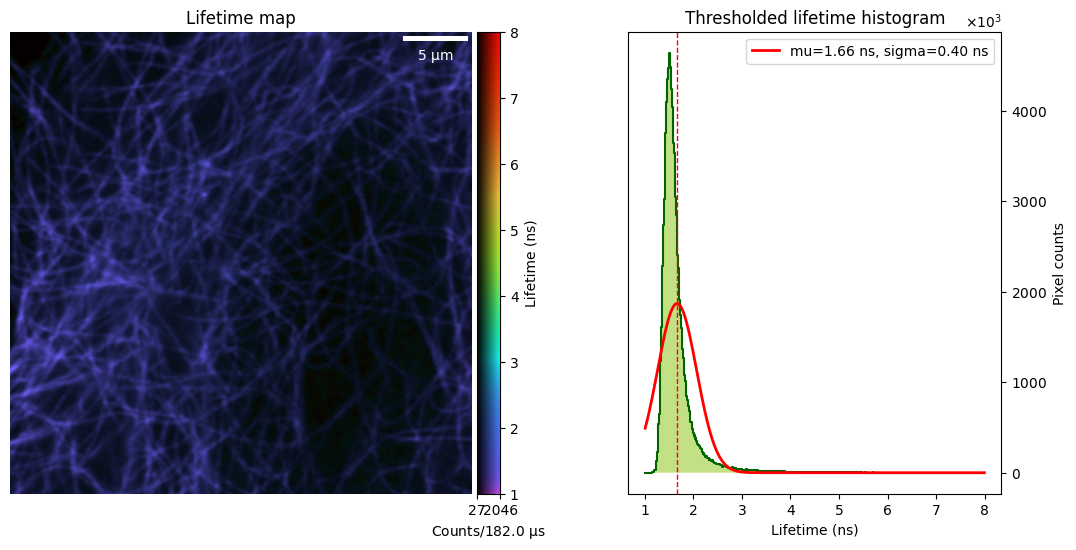

In [39]:
# ── Visualisation ─────────────────────────────────────────────────────────

graph.plot_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=LIFETIME_BOUNDS,
    crop=30,
    threshold=THRESHOLD,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

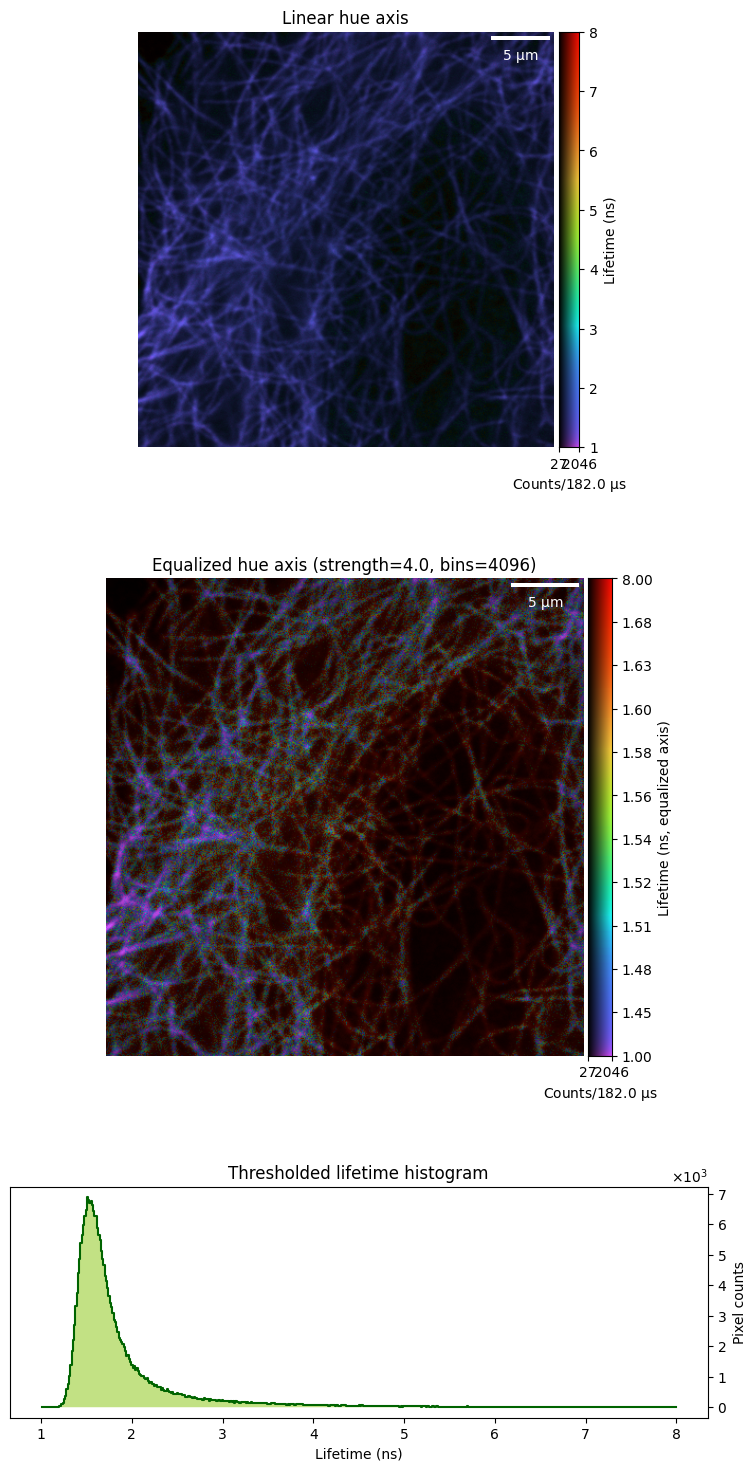

In [40]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=LIFETIME_BOUNDS,
    crop=30,
    threshold=THRESHOLD,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)


## Optional Export

Set `FILENAME_OUTPUT` to a valid `.h5` path to save the fit results and intensity map.
Leave it as `None` to skip.


In [ ]:
if FILENAME_OUTPUT is not None:
    fit_source_path = PIPELINE_H5 if "PIPELINE_H5" in globals() else FILENAME_OUTPUT
    fit_mode = "append"
    fit_output_path = None
    apr_output_data_path = APR_OUTPUT_DATA_PATH if DO_APR and "APR_OUTPUT_DATA_PATH" in globals() else ""
    apr_output_run_id = APR_OUTPUT_RUN_ID if DO_APR and "APR_OUTPUT_RUN_ID" in globals() else ""
    fit_source_data_path = apr_output_data_path or f"/raw/{CALIBRATION_PRODUCT}"
    common_attrs = {
        "source_data_path": fit_source_data_path,
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz,
        "laser_period_ns": laser_period_ns,
    }
    products = [
        H5OutputProduct("intensity", intensity, attrs={**common_attrs, "data_role": "integrated_intensity", "axis_order": "y,x"}),
        H5OutputProduct("tau_ns", tau, attrs={**common_attrs, "data_role": "lifetime_tau", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("fit_params", fit_stack, attrs={**common_attrs, "data_role": "fit_parameter_stack", "axis_order": "fit_parameter,y,x", "fit_stack_names_json": fit_stack_names}),
        H5OutputProduct("decay_sum", data_summed, attrs={**common_attrs, "data_role": "channel_summed_decay", "axis_order": "y,x,time_bin"}),
        H5OutputProduct("irf", irf_summed, attrs={**common_attrs, "data_role": "channel_summed_irf", "axis_order": "time_bin"}),
    ]
    for name, arr in fit_maps.items():
        arr = np.asarray(arr)
        if arr.dtype.kind not in "fiu":
            continue
        products.append(
            H5OutputProduct(
                f"fit_maps/{name}",
                arr,
                attrs={**common_attrs, "data_role": f"fit_map_{name}", "axis_order": "y,x"},
            )
        )
    print("Products to export:")
    for product in products:
        arr = np.asarray(product.data)
        print(f"  {product.name}: shape {arr.shape}, dtype {arr.dtype}")

    target_path, output_run_id = write_h5_output_run(
        fit_source_path,
        "lifetime_fit",
        products,
        mode=fit_mode,
        output_path=fit_output_path,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="Lifetime fit",
        algorithm_name="Alignment.generate_fit_maps",
        parameters={
            "fit_initial_tau_ns": FIT_INITIAL_TAU,
            "fit_initial_dT_ns": FIT_INITIAL_dT,
            "fit_initial_C": FIT_INITIAL_C,
            "fit_mode_pixel": FIT_MODE_PIXEL,
            "fit_type_pixel": FIT_TYPE_PIXEL,
            "threshold_fraction": THRESHOLD,
            "fit_stack_names": fit_stack_names,
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
            "apr_output_run_id": apr_output_run_id,
            "apr_output_data_path": apr_output_data_path,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": data_summed.shape[0],
            "output_nx": data_summed.shape[1],
            "output_time_bins": data_summed.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "sum_channels_with_skew_correction",
            "apr_output_run_id": apr_output_run_id,
            "apr_output_data_path": apr_output_data_path,
        },
        axes=[H5OutputProduct("time_ns", t, attrs={"axis": "time", "units": "ns"})],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x,time_bin",
            "output_data_path": "/output/{run_id}/products/tau_ns",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (FILENAME_OUTPUT = None).")


Products to export:
intensity
  intensity: shape (512, 512), dtype float64
tau_ns
  tau_ns: shape (512, 512), dtype float64
fit_stack
  fit_stack: shape (6, 512, 512), dtype float64
data_summed
  data_summed: shape (512, 512, 91), dtype float64
irf_summed
  irf_summed: shape (91,), dtype float64
fit_maps/C
  fit_maps/C: shape (512, 512), dtype float64
fit_maps/C_err
  fit_maps/C_err: shape (512, 512), dtype float64
fit_maps/dT
  fit_maps/dT: shape (512, 512), dtype float64
fit_maps/dT_err
  fit_maps/dT_err: shape (512, 512), dtype float64
fit_maps/tau
  fit_maps/tau: shape (512, 512), dtype float64
fit_maps/tau_err
  fit_maps/tau_err: shape (512, 512), dtype float64
Saved lifetime_fit_003 -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_fit_workflow.h5


In [ ]:
show_h5_structure_html(FILENAME_OUTPUT)    

'<script>\n(function () {\n  // Expand / collapse ALL groups in the widget\n  function h5All(widgetId, open) {\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'details.h5-branch\').forEach(function(d) {\n      d.open = open;\n    });\n  }\n\n  // Expand / collapse all groups at a specific depth inside a widget\n  function h5LevelToggle(widgetId, depth, open, btn) {\n    // Stop the click from toggling the parent <details>\n    if (btn) { btn.closest(\'details\') && (event || window.event) && (event || window.event).stopPropagation(); }\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'li.h5-li-group[data-depth="\' + depth + \'"]\').forEach(function(li) {\n      var det = li.querySelector(\':scope > details.h5-branch\');\n      if (det) det.open = open;\n    });\n  }\n\n  // Expose globally so onclick= attributes work\n  window.h5All = h5All;\n  window.h5LevelToggle = h5LevelTogg